In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [30]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [31]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
def category(x):
    if x["BMI"]>0 and x["BMI"]<18.5:
        return "Underweight"
    elif x["BMI"]>=18.5 and x["BMI"]<=24.9:
        return "Healthy"
    elif x["BMI"]>=25 and x["BMI"]<=29.9:
        return "Overweight"
    elif x["BMI"]>=30:
        return "Obesity"
    

In [33]:
df["BMI_Category"]=df.apply(category, axis=1)
# or
# df["BMI_Category"]=pd.cut(df.BMI, bins=[0,18.5,24.9,29.9,30], labels=["Underweight","Healthy","Overweight","Obesity"])

In [34]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
0,6,148,72,35,0,33.6,0.627,50,1,Obesity
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Healthy
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obesity
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obesity
764,2,122,70,27,0,36.8,0.340,27,0,Obesity
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obesity


In [35]:
df[df.BMI_Category.isna()==True]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
9,8,125,96,0,0,0.0,0.232,54,1,None
49,7,105,0,0,0,0.0,0.305,24,0,None
60,2,84,0,0,0,0.0,0.304,21,0,None
81,2,74,0,0,0,0.0,0.102,22,0,None
145,0,102,75,23,0,0.0,0.572,21,0,None
371,0,118,64,23,89,0.0,1.731,21,0,None
426,0,94,0,0,0,0.0,0.256,25,0,None
494,3,80,0,0,0,0.0,0.174,22,0,None
522,6,114,0,0,0,0.0,0.189,26,0,None
684,5,136,82,0,0,0.0,0.640,69,0,None


In [36]:
df=df.dropna()

<Axes: xlabel='BMI', ylabel='Count'>

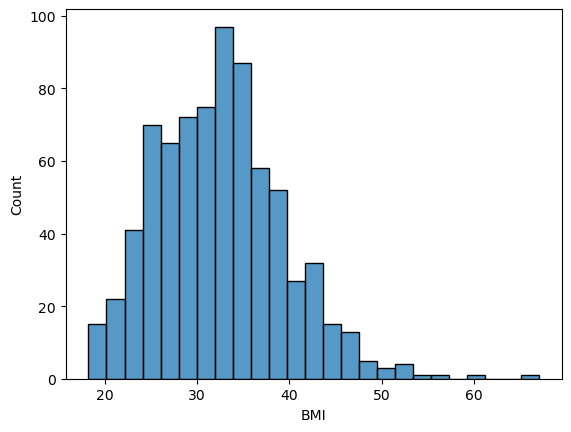

In [37]:
sns.histplot(data=df,x="BMI")

In [47]:
x=df.drop(["BMI_Category","Outcome"],axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[73 24]
 [26 29]]
0.6710526315789473
              precision    recall  f1-score   support

           0       0.74      0.75      0.74        97
           1       0.55      0.53      0.54        55

    accuracy                           0.67       152
   macro avg       0.64      0.64      0.64       152
weighted avg       0.67      0.67      0.67       152



In [50]:
x=df.drop(["BMI_Category","Outcome"],axis=1)
y=df["Outcome"]
for i in range(21,46,2):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    # print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))

0.7171052631578947
0.6907894736842105
0.7039473684210527
0.7039473684210527
0.7171052631578947
0.7368421052631579
0.7171052631578947
0.7105263157894737
0.7105263157894737
0.7105263157894737
0.7105263157894737
0.7105263157894737
0.7105263157894737


In [52]:
x=df.drop(["BMI_Category","Outcome"],axis=1)
x=pd.get_dummies(x,drop_first=True)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)
for i in range(21,46,2):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scale,y_train)
    y_pred=knn.predict(x_test_scale)
    # print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))

0.75
0.75
0.756578947368421
0.743421052631579
0.756578947368421
0.75
0.75
0.743421052631579
0.743421052631579
0.75
0.75
0.743421052631579
0.756578947368421


In [54]:
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [60]:
# weight=150, length1=12, length2=15, length3=14, height=7, width=6
x=df.drop("Species",axis=1)
y=df["Species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)
for i in range(33,47,1):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scale,y_train)
    y_pred=knn.predict(x_test_scale)
    # print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))
    print("Prediction for given values:",knn.predict(scaler.transform([[150,12,15,14,7,6]])))

0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.59375
Prediction for given values: ['Perch']
0.53125
Prediction for given values: ['Perch']
0.53125
Prediction for given values: ['Perch']
0.53125
Prediction for given values: ['Perch']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-p